In [1]:
# ============================================
# CELDA 1: Importaciones
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas")

✅ Librerías importadas


In [2]:
# ============================================
# CELDA 2: Carga del dataset SECOM
# ============================================

# SECOM tiene 590 sensores separados por espacios
# Los valores faltantes están marcados como NaN
df = pd.read_csv('../data/secom.data', 
                 sep=' ', 
                 header=None)

# Etiquetas: -1 = producto OK, 1 = producto FAIL
labels = pd.read_csv('../data/secom_labels.data',
                     sep=' ',
                     header=None,
                     usecols=[0],
                     names=['label'])

# Unimos sensores con etiquetas
df['label'] = labels['label']

print("✅ Dataset cargado correctamente")
print(f"📊 Filas     : {df.shape[0]:,}")
print(f"📊 Sensores  : {df.shape[1]-1}")
print(f"\nDistribución de clases:")
print(f"  ✅ Productos OK   (-1): {(labels['label']==-1).sum():,}")
print(f"  ❌ Productos FAIL ( 1): {(labels['label']==1).sum():,}")
print(f"\n⚠️  Desbalance: {(labels['label']==1).sum()/(len(labels))*100:.1f}% son fallas")

✅ Dataset cargado correctamente
📊 Filas     : 1,567
📊 Sensores  : 590

Distribución de clases:
  ✅ Productos OK   (-1): 1,463
  ❌ Productos FAIL ( 1): 104

⚠️  Desbalance: 6.6% son fallas


📊 Sensores con valores faltantes: 538
📊 Sensores completamente vacíos : 0
📊 Sensores sin ningún faltante  : 52


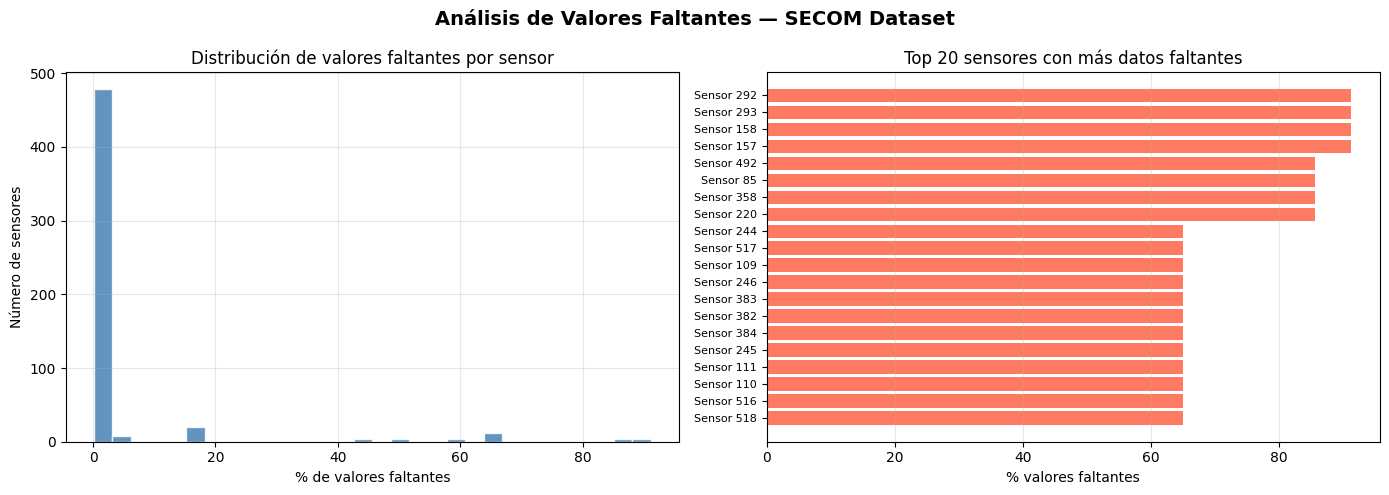

✅ Gráfica guardada


In [3]:
# ============================================
# CELDA 3: Análisis de valores faltantes
# ============================================

# Calculamos % de valores faltantes por sensor
missing = df.drop(columns=['label']).isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

print(f"📊 Sensores con valores faltantes: {(missing > 0).sum()}")
print(f"📊 Sensores completamente vacíos : {(missing == len(df)).sum()}")
print(f"📊 Sensores sin ningún faltante  : {(missing == 0).sum()}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Valores Faltantes — SECOM Dataset',
             fontsize=14, fontweight='bold')

# Histograma de % faltantes
ax1 = axes[0]
ax1.hist(missing_pct[missing_pct > 0], bins=30, 
         color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel('% de valores faltantes')
ax1.set_ylabel('Número de sensores')
ax1.set_title('Distribución de valores faltantes por sensor')
ax1.grid(True, alpha=0.3)

# Top 20 sensores con más faltantes
ax2 = axes[1]
top20 = missing_pct.head(20)
ax2.barh(range(20), top20.values, color='tomato', alpha=0.85)
ax2.set_yticks(range(20))
ax2.set_yticklabels([f'Sensor {i}' for i in top20.index], fontsize=8)
ax2.set_xlabel('% valores faltantes')
ax2.set_title('Top 20 sensores con más datos faltantes')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../src/missing_values.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

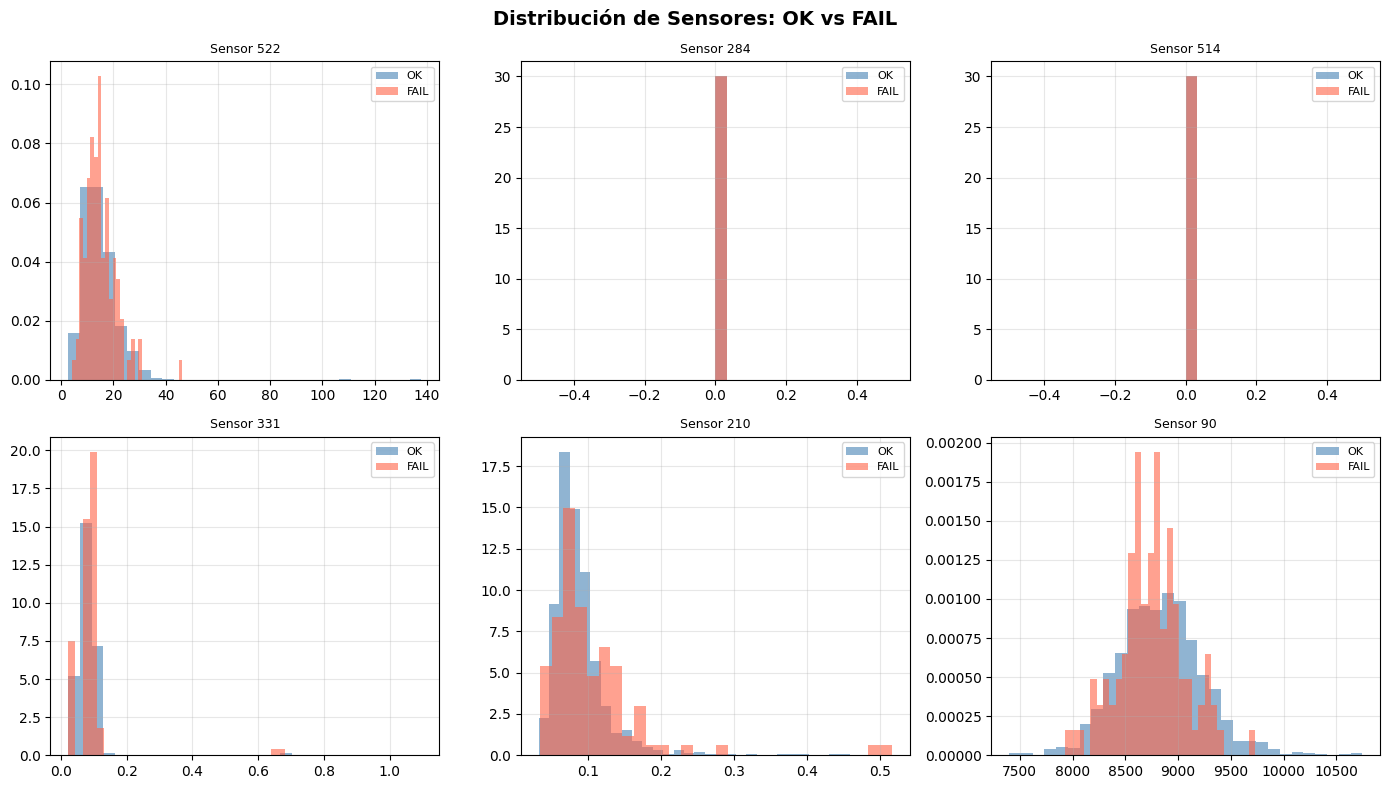

✅ Gráfica guardada


In [4]:
# ============================================
# CELDA 4: Distribución de sensores clave
# ============================================

# Separamos OK vs FAIL para comparar
df_ok   = df[df['label'] == -1].drop(columns=['label'])
df_fail = df[df['label'] ==  1].drop(columns=['label'])

# Visualizamos 6 sensores aleatorios
np.random.seed(42)
sample_sensors = np.random.choice(df.columns[:-1], 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribución de Sensores: OK vs FAIL',
             fontsize=14, fontweight='bold')

for ax, sensor in zip(axes.flatten(), sample_sensors):
    ok_vals   = df_ok[sensor].dropna()
    fail_vals = df_fail[sensor].dropna()
    
    ax.hist(ok_vals, bins=30, alpha=0.6, 
            color='steelblue', label='OK', density=True)
    ax.hist(fail_vals, bins=30, alpha=0.6, 
            color='tomato', label='FAIL', density=True)
    ax.set_title(f'Sensor {sensor}', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/sensor_distributions.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

📊 Top 10 sensores más correlacionados con fallas:
59     0.155796
103    0.151203
510    0.131593
348    0.130180
158    0.121258
431    0.120851
293    0.114494
111    0.113950
434    0.112116
430    0.110067


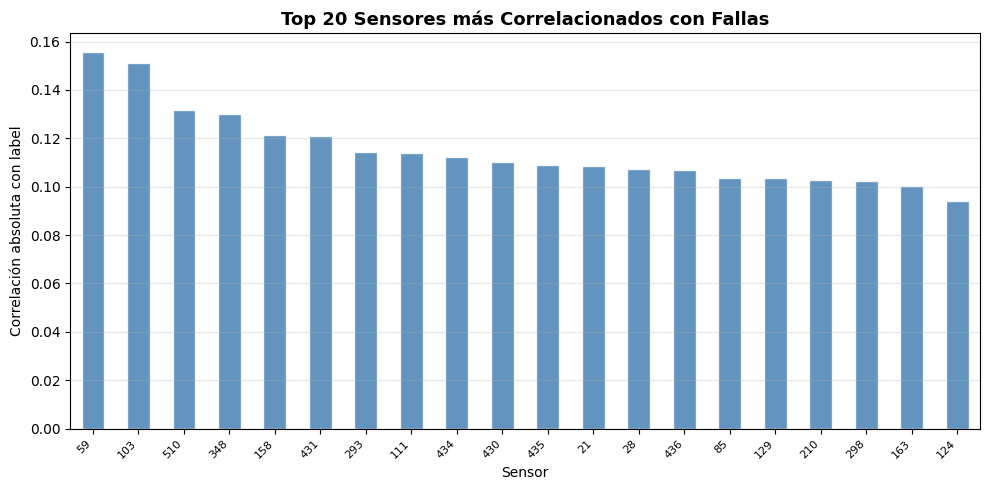

✅ Gráfica guardada


In [5]:
# ============================================
# CELDA 5: Correlación con la etiqueta
# ============================================

# ¿Qué sensores están más correlacionados con las fallas?
correlations = df.drop(columns=['label']).corrwith(
    df['label']
).abs().sort_values(ascending=False)

print(f"📊 Top 10 sensores más correlacionados con fallas:")
print(correlations.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
correlations.head(20).plot(kind='bar', ax=ax, 
                            color='steelblue', 
                            edgecolor='white',
                            alpha=0.85)
ax.set_title('Top 20 Sensores más Correlacionados con Fallas',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sensor')
ax.set_ylabel('Correlación absoluta con label')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../src/sensor_correlations.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

In [6]:
# ============================================
# CELDA 6: Resumen
# ============================================

print("=" * 50)
print("RESUMEN — Exploratory Analysis")
print("=" * 50)
print(f"""
Dataset   : SECOM Semiconductor Manufacturing
Muestras  : {df.shape[0]:,} productos
Sensores  : {df.shape[1]-1}
Fallas    : {(df['label']==1).sum()} ({(df['label']==1).mean()*100:.1f}%)
OK        : {(df['label']==-1).sum()} ({(df['label']==-1).mean()*100:.1f}%)

Calidad de datos:
  Sensores con faltantes : {(missing>0).sum()}
  Sensores 100% vacíos   : {(missing==len(df)).sum()}

Hallazgos clave:
  ⚠️  Dataset muy desbalanceado (6% fallas)
  ⚠️  Muchos sensores tienen valores faltantes
  ✅  Algunos sensores muestran diferencias 
      claras entre OK y FAIL

Siguiente paso → 02_preprocessing.ipynb
""")

RESUMEN — Exploratory Analysis

Dataset   : SECOM Semiconductor Manufacturing
Muestras  : 1,567 productos
Sensores  : 590
Fallas    : 104 (6.6%)
OK        : 1463 (93.4%)

Calidad de datos:
  Sensores con faltantes : 538
  Sensores 100% vacíos   : 0

Hallazgos clave:
  ⚠️  Dataset muy desbalanceado (6% fallas)
  ⚠️  Muchos sensores tienen valores faltantes
  ✅  Algunos sensores muestran diferencias 
      claras entre OK y FAIL

Siguiente paso → 02_preprocessing.ipynb

